In [29]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[1])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon, L1WaveletRecon
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter,filtfilt


## My files
from ksp_plot_helpers import plot_ksp_data_multichannel, find_and_plot_acquired_region
from raw_data_utils import get_kspace_data, get_TR
from resp_signal_functions import resp_signal_all_slices, resp_signal_single_slice, resp_signal_center_sample_single_slice
from resp_signal_plot_functions import *
import gating_functions
from pca_helper import pca_resp_signal
from save_data_helpers import *

In [30]:
ksp_512 = read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))

### Alternative gating

In [32]:
spoke_bins_mat = loadmat('/home/lilianae/projects/naf_clean/matlab_comparison/spoke_20_gates.mat')
spoke_gates = spoke_bins_mat['spoke_gates']
num_gates = 20
spoke_bins_from_mat = []
for i in range(1, num_gates+1):
    gate_name = f'gate{i}'
    gate_data = spoke_gates[gate_name][0][0].ravel()
    spoke_bins_from_mat.append(gate_data)

print(f'len(spoke_bins) = {len(spoke_bins_from_mat)}')
print(f'spoke_bins_from_mat[0].shape = {spoke_bins_from_mat[0].shape}')

len(spoke_bins) = 20
spoke_bins_from_mat[0].shape = (91,)


In [ ]:
def ga_2d_readout_from_spokes(kmax, spoke_list, num_points):
    """2D golden angle kspace trajectory"""
    tmp = np.linspace(-kmax, kmax, num_points)
    k = np.zeros((len(spoke_list), num_points, 2))
    
    ga = np.pi / ((1 + np.sqrt(5)) / 2)  # Golden angle
    
    for i in range(len(spoke_list)):
        # print(f'spoke[{i}] = {spoke_list[i]}')
        phi = (spoke_list[i] * ga) % (2 * np.pi)
        k[i, :, 0] = tmp * np.cos(phi)
        k[i, :, 1] = tmp * np.sin(phi)
    
    return k


def get_ga_coords_3d_from_spokes(img_shape, spoke_list, num_points):
    """Generate 3D stack-of-stars golden angle coordinates"""
    # Generate 2D golden angle spokes
    coords_2d = ga_2d_readout_from_spokes(img_shape[1]//2, spoke_list, num_points)
    
    # Stack across partitions with kz encoding
    shape_3d = [img_shape[0]] + list(coords_2d.shape)
    shape_3d[3] += 1  # Add dimension for kz
    
    coords_3d = np.zeros(shape_3d, dtype=coords_2d.dtype)
    slice_coords = np.linspace(-img_shape[0]/2., img_shape[0]/2., img_shape[0])
    
    for i in range(img_shape[0]):
        coords_3d[i, :, :, 1:] = coords_2d  # kx, ky
        coords_3d[i, :, :, 0] = slice_coords[i]  # kz
    
    return coords_3d

In [37]:
data_bins = []
spoke_bins = []
num_coils, num_slices, num_spokes, num_samples = ksp_512.shape
img_shape = (num_slices, num_samples, num_samples)

for i in range(num_gates):
    num_spokes_per_gate = len(spoke_bins_from_mat[i])
    spokes_for_gate = spoke_bins_from_mat[i]
    print(spokes_for_gate)
    current_ksp = np.zeros((num_coils, num_slices, num_spokes_per_gate, num_samples), dtype=complex)
    current_coords = get_ga_coords_3d_from_spokes(img_shape=img_shape, spoke_list=spokes_for_gate, num_points=num_samples)

    for j,spoke in enumerate(spokes_for_gate):
        current_ksp[:, :, j, :] = ksp_512[:, :, spoke, :]

    print(f'Gate {i}:')
    print(f'current_coords.shape = {current_coords.shape}')
    print(f'current_ksp.shape - {current_ksp.shape}')

    data_bins.append(current_ksp)
    spoke_bins.append(current_coords)

[ 311  312  313  314  322  323  324  332  333  334  942  944  952  953
  955  965  966  974  975  976  977 1101 1102 1103 1111 1112 1113 1114
 1123 1124 1360 1362 1365 1373 1374 1387 1388 1389 1390 1391 1393 1394
 1395 1396 1397 1398 1400 1401 1404 1405 1407 1408 1409 1410 1589 1590
 1591 1597 1598 1601 1602 1607 1608 1610 1619 1621 1622 1623 1625 1633
 1634 1635 1636 1644 1645 1654 1865 1866 1871 1872 1873 1874 1875 1876
 1881 1882 1883 1884 1885 1900 1901]
spoke[0] = 311
spoke[1] = 312
spoke[2] = 313
spoke[3] = 314
spoke[4] = 322
spoke[5] = 323
spoke[6] = 324
spoke[7] = 332
spoke[8] = 333
spoke[9] = 334
spoke[10] = 942
spoke[11] = 944
spoke[12] = 952
spoke[13] = 953
spoke[14] = 955
spoke[15] = 965
spoke[16] = 966
spoke[17] = 974
spoke[18] = 975
spoke[19] = 976
spoke[20] = 977
spoke[21] = 1101
spoke[22] = 1102
spoke[23] = 1103
spoke[24] = 1111
spoke[25] = 1112
spoke[26] = 1113
spoke[27] = 1114
spoke[28] = 1123
spoke[29] = 1124
spoke[30] = 1360
spoke[31] = 1362
spoke[32] = 1365
spoke[3

Original shape: (15, 58, 91, 512)
ncoils=15, nslices=58, nsamples=512, nspokes=91
ksp_data_flat.shape = (15, 58, 46592)
Data min: 4.656612873077393e-10
Data max: 0.001304625207075733
Data mean: 8.659467897406925e-06
Data median: 2.753314266246253e-06
Data std: 3.2533725049889785e-05
Non-zero elements: 2702336 / 2702336


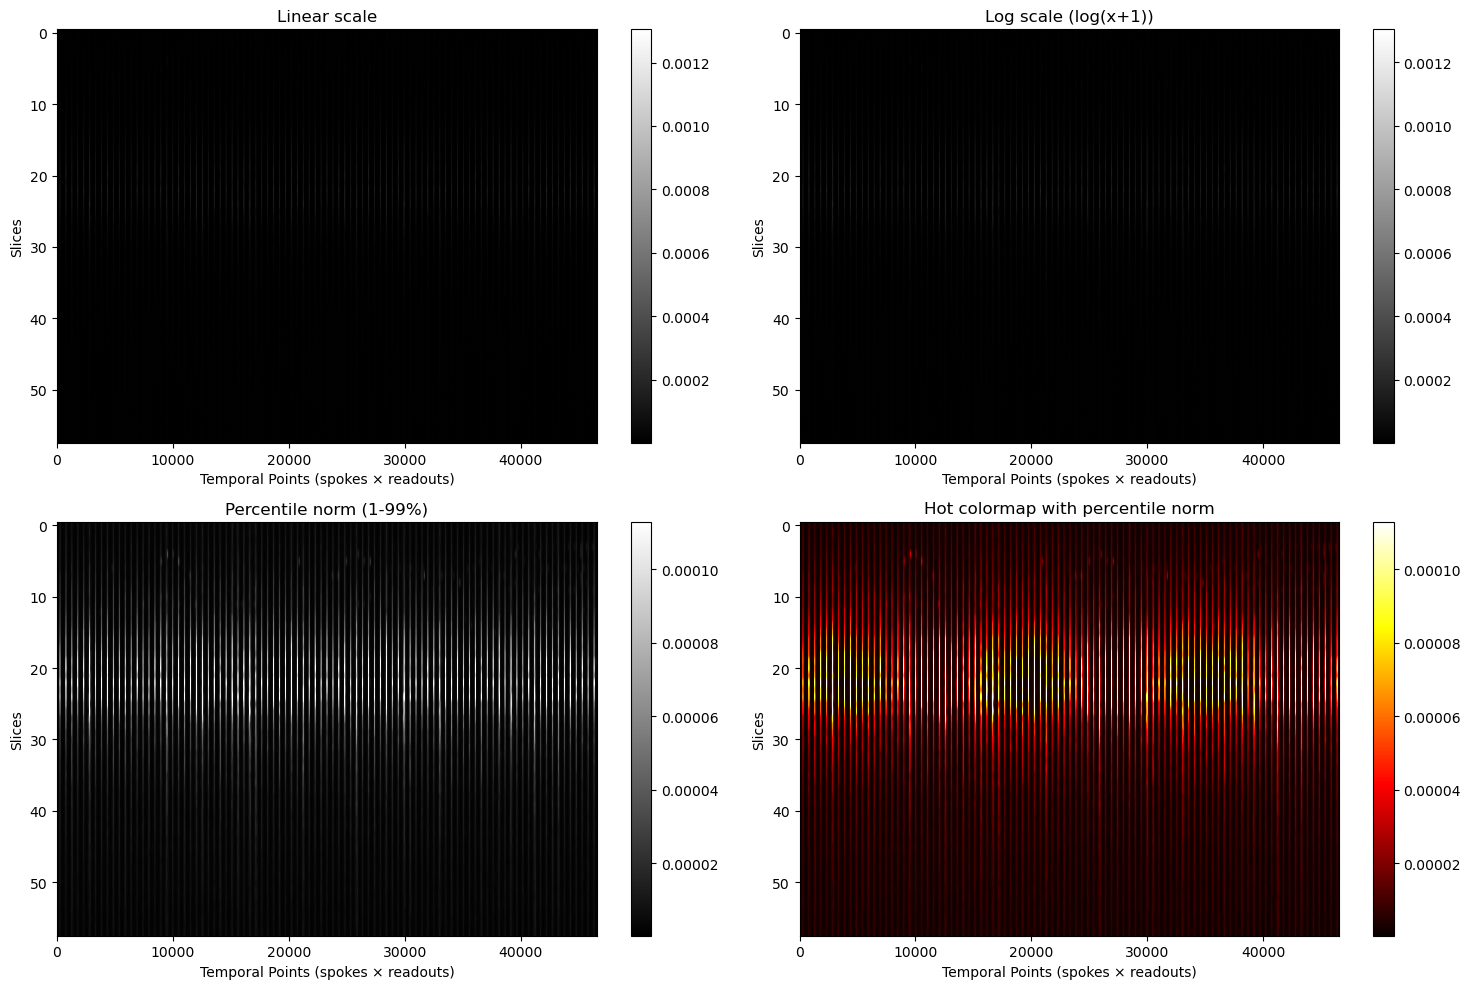

In [38]:
def plot_ksp_data_gate_debug(ksp_data, coil_idx, title=""):
    """Plot ksp data for slices vs (spoke,sample) dimension collapsed"""
    
    print(f"Original shape: {ksp_data.shape}")
    # Original: (ncoils, nspokes, nslices, nsamples)
    
    # ksp_data = ksp_data.transpose(0, 2, 1, 3)
    # print(f"After transpose: {ksp_data.shape}")
    
    ncoils, nslices, nspokes, nsamples = ksp_data.shape
    print(f"ncoils={ncoils}, nslices={nslices}, nsamples={nsamples}, nspokes={nspokes}")
    
    # Reshape to collapse spokes and samples into one temporal dimension
    ksp_data_flat = ksp_data.reshape(ncoils, nslices, -1)
    print(f"ksp_data_flat.shape = {ksp_data_flat.shape}")
    
    # Extract data for visualization
    plot_data = np.abs(ksp_data_flat[coil_idx, :, :])  # (nslices, temporal_pts)
    
    # DEBUGGING: Check data statistics
    print(f"Data min: {plot_data.min()}")
    print(f"Data max: {plot_data.max()}")
    print(f"Data mean: {plot_data.mean()}")
    print(f"Data median: {np.median(plot_data)}")
    print(f"Data std: {plot_data.std()}")
    print(f"Non-zero elements: {np.count_nonzero(plot_data)} / {plot_data.size}")
    
    # Try different visualizations to see what works
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Linear scale
    im1 = axes[0,0].imshow(plot_data, cmap='gray', aspect='auto')
    axes[0,0].set_title("Linear scale")
    plt.colorbar(im1, ax=axes[0,0])
    
    # Plot 2: Log scale
    im2 = axes[0,1].imshow(np.log(plot_data + 1), cmap='gray', aspect='auto')
    axes[0,1].set_title("Log scale (log(x+1))")
    plt.colorbar(im2, ax=axes[0,1])
    
    # Plot 3: Percentile-based normalization
    vmin, vmax = np.percentile(plot_data, [1, 99])
    im3 = axes[1,0].imshow(plot_data, cmap='gray', aspect='auto', 
                           vmin=vmin, vmax=vmax)
    axes[1,0].set_title(f"Percentile norm (1-99%)")
    plt.colorbar(im3, ax=axes[1,0])
    
    # Plot 4: Hot colormap (better for k-space)
    im4 = axes[1,1].imshow(plot_data, cmap='hot', aspect='auto',
                           vmin=vmin, vmax=vmax)
    axes[1,1].set_title("Hot colormap with percentile norm")
    plt.colorbar(im4, ax=axes[1,1])
    
    for ax in axes.flat:
        ax.set_xlabel("Temporal Points (spokes × readouts)")
        ax.set_ylabel("Slices")
    
    plt.tight_layout()
    plt.show()


plot_ksp_data_gate_debug(data_bins[0], coil_idx=8)

Average value, slices vs samples per gate = 1.5898760304199664e-05
Average value, readouts vs spokes per gate = 3.678335401913716e-05
Average value, slices vs center sample per gate = 0.00013978415757194977


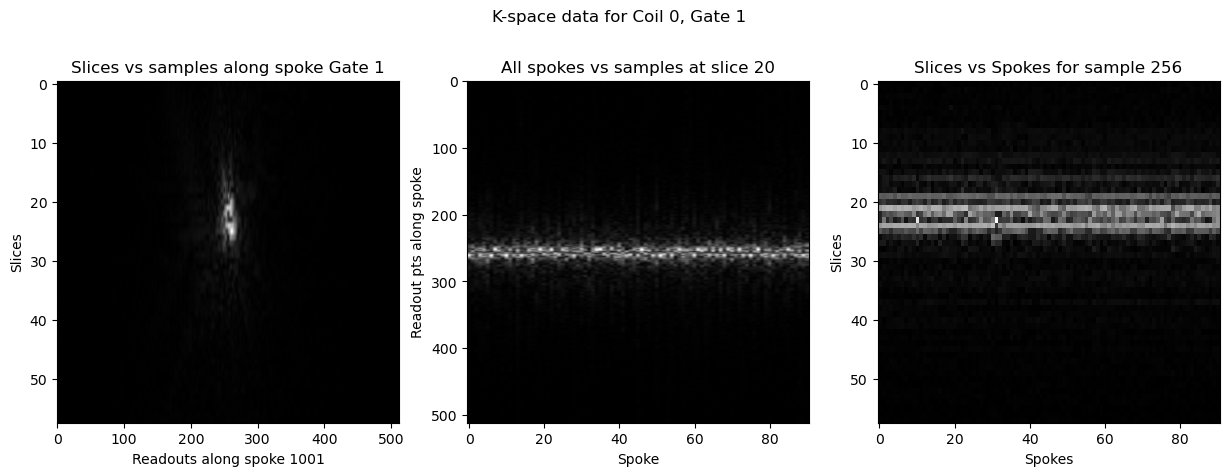

Average value, slices vs samples per gate = 1.5907823586528598e-05
Average value, readouts vs spokes per gate = 3.6788745863046355e-05
Average value, slices vs center sample per gate = 0.00013832680745886188


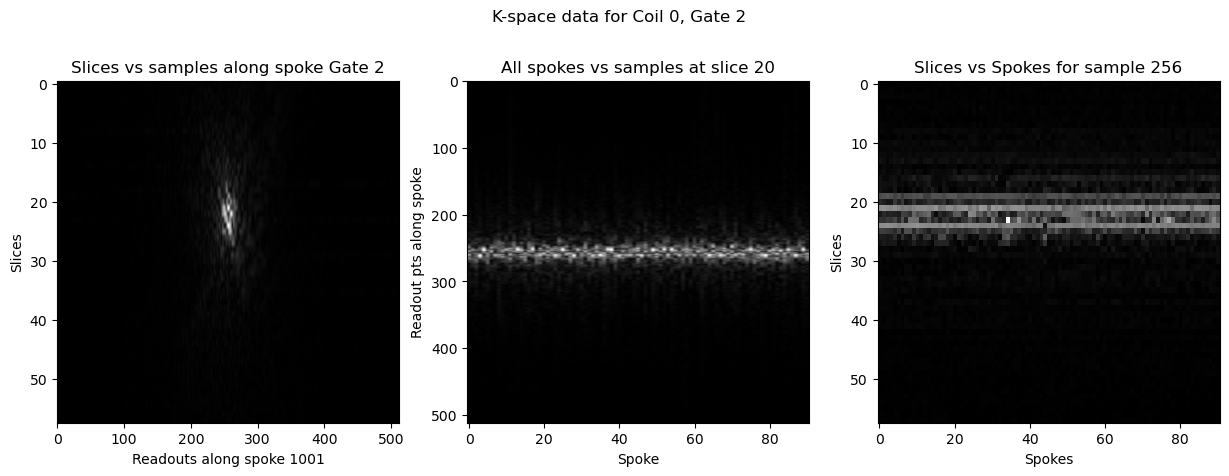

Average value, slices vs samples per gate = 1.68330359384494e-05
Average value, readouts vs spokes per gate = 3.7163345619106356e-05
Average value, slices vs center sample per gate = 0.00013940443522302413


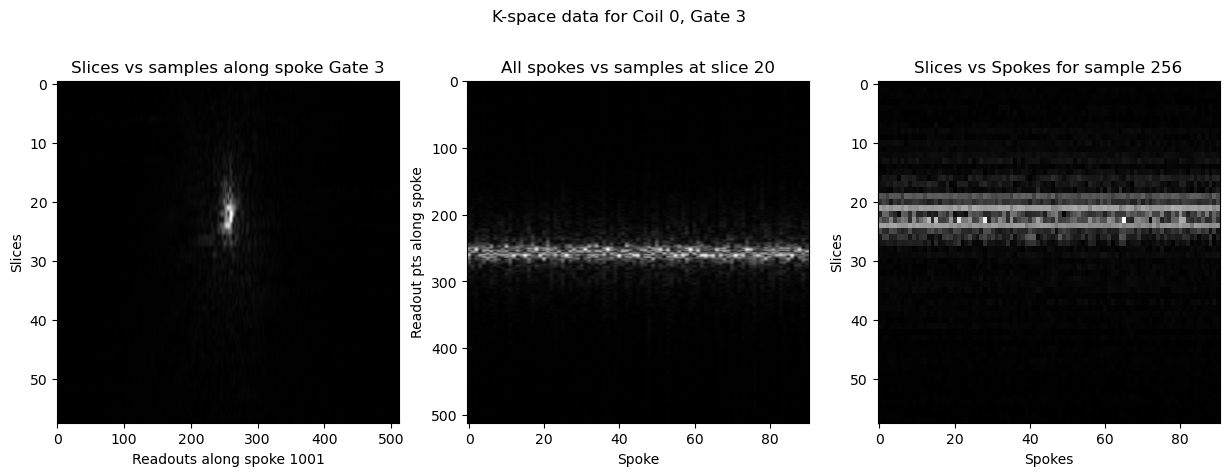

Average value, slices vs samples per gate = 1.5884891529925418e-05
Average value, readouts vs spokes per gate = 3.701895070131427e-05
Average value, slices vs center sample per gate = 0.0001372460028935916


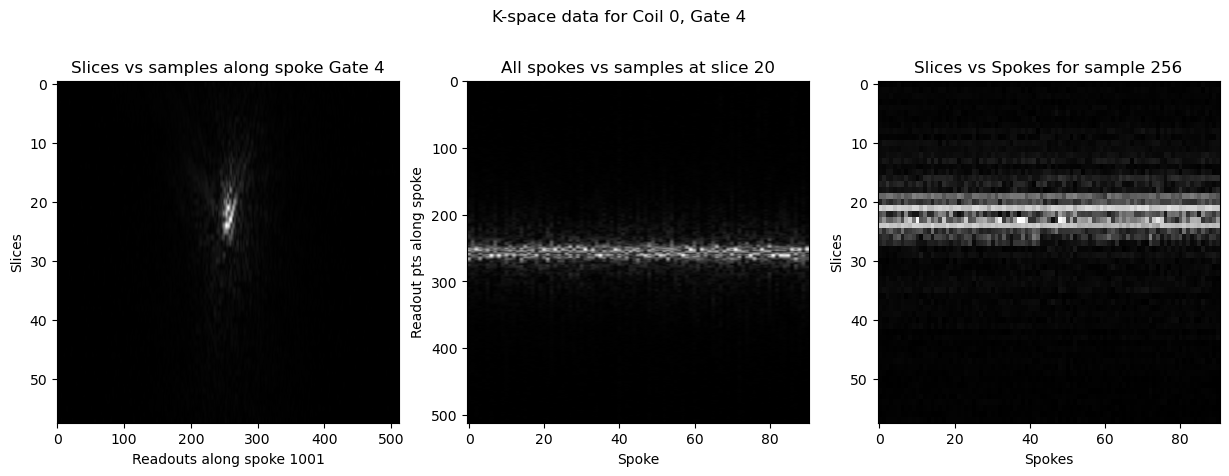

Average value, slices vs samples per gate = 1.6142309937119778e-05
Average value, readouts vs spokes per gate = 3.6665136646696056e-05
Average value, slices vs center sample per gate = 0.00014044327039651507


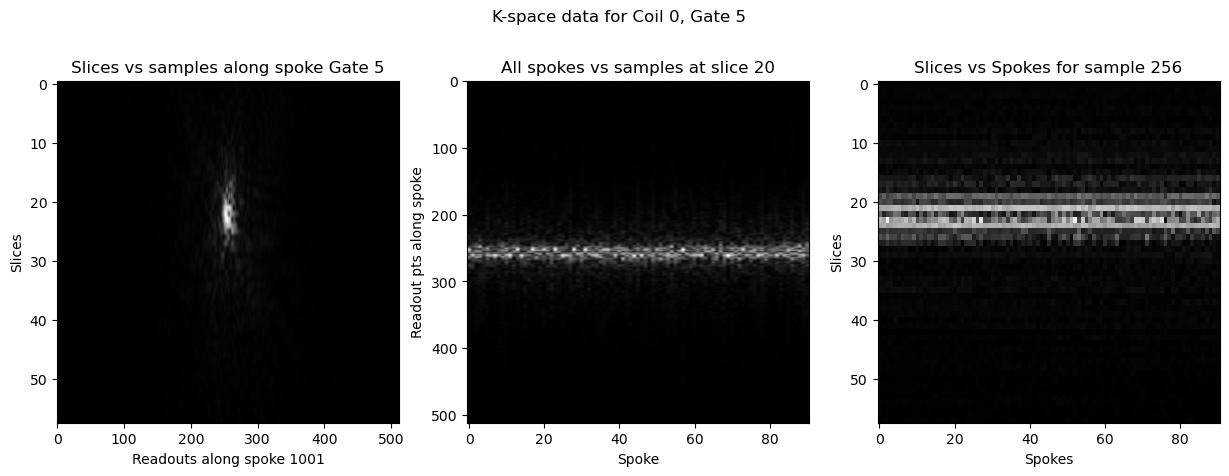

In [39]:
def plot_ksp_data_new(ksp_data, coil_idx, center_slice = None, spoke_idx =0, center_sample = None, title_info=""):

    # ksp_data = ksp_data.transpose(0,2,1,3)
    ## Get all dims 
    ncoils, nslices, nspokes, nsamples= ksp_data.shape

    ## If center idx not given, assume it is middle
    if center_slice is None:
        center_slice = nslices // 2
    
    if center_sample is None:
        center_sample = nsamples //2

    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    ## Plot spokes vs slices
    axs[0].imshow(np.abs(ksp_data[0, :, 0, :]), cmap='gray', aspect=nsamples/nslices)
    print(f'Average value, slices vs samples per gate = {np.mean(np.abs(ksp_data[0, :, 0, :]))}')
    axs[0].set_xlabel(f"Readouts along spoke {spoke_idx}")
    axs[0].set_ylabel("Slices")
    axs[0].set_title(f"Slices vs samples along spoke {title_info}")

    ## Plot spokes vs samples for center idx 
    axs[1].imshow(np.abs(ksp_data[0, center_slice, :, :]).T, cmap='gray', aspect=nspokes/nsamples)
    print(f'Average value, readouts vs spokes per gate = {np.mean(np.abs(ksp_data[0, center_slice, :, :]).T)}')
    axs[1].set_xlabel("Spoke")
    axs[1].set_ylabel("Readout pts along spoke")
    axs[1].set_title(f"All spokes vs samples at slice {center_slice}")

    ## Plot all slices vs center sample
    axs[2].imshow(np.abs(ksp_data[0, :, :, center_sample]), cmap='gray', aspect=nspokes/nslices)
    print(f'Average value, slices vs center sample per gate = {np.mean(np.abs(ksp_data[0, :, :, center_sample]))}')
    axs[2].set_xlabel("Spokes")
    axs[2].set_ylabel("Slices")
    axs[2].set_title(f"Slices vs Spokes for sample {center_sample}")
    
    fig.suptitle(f"K-space data for Coil {coil_idx}, {title_info}")

    plt.show()

for i in range(5):
    plot_ksp_data_new(data_bins[i], coil_idx=0, center_slice=20, spoke_idx=1001
                      , title_info=f"Gate {i+1}")

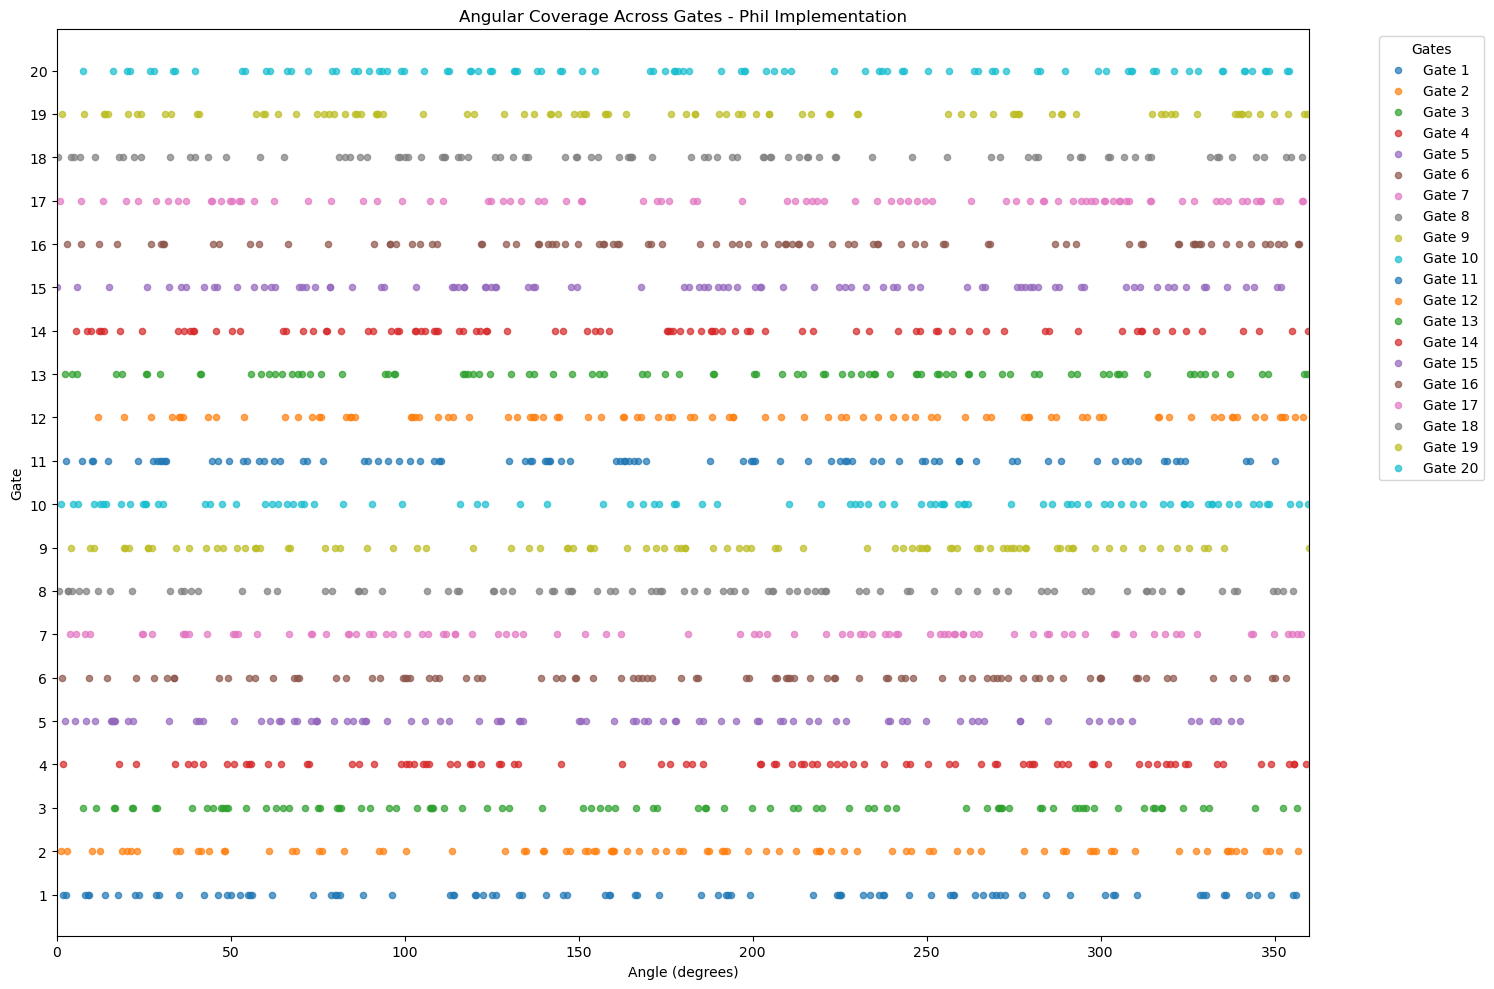

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Example: assuming spoke_bins is a list of arrays, one per gate
# spoke_bins[gate_idx].shape = (num_slices, num_spokes, num_samples, ndims)

num_gates = len(spoke_bins)
middle_slice = 20
num_samples = 512

plt.figure(figsize=(15, 10))

for gate_idx in range(num_gates):
    coords = spoke_bins[gate_idx]
    
    # Extract center of k-space (or first readout point) for middle slice
    kx = coords[middle_slice, :, num_samples//2, 2]  # x
    ky = coords[middle_slice, :, num_samples//2, 1]  # y
    
    # Compute angles in degrees [0, 360)
    angles_deg = np.degrees(np.arctan2(ky, kx)) % 360
    
    # Plot each angle as a dot at the corresponding gate index
    plt.scatter(angles_deg, np.full_like(angles_deg, gate_idx + 1), label=f'Gate {gate_idx + 1}', alpha=0.7, s=20)

plt.xlabel("Angle (degrees)")
plt.ylabel("Gate")
plt.yticks(range(1, num_gates + 1))
plt.xlim(0, 360)
plt.title("Angular Coverage Across Gates - Phil Implementation")
plt.legend(title="Gates", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [43]:
import save_data_helpers

save_data_helpers.write_pickle(data_bins, '/data/lilianae/data_and_spoke_bins/data_bin_20sp_phil_gating.pkl')
save_data_helpers.write_pickle(spoke_bins, '/data/lilianae/data_and_spoke_bins/spoke_bins_20sp_phil_gating.pkl')

Successfully saved as /data/lilianae/data_and_spoke_bins/data_bin_20sp_phil_gating.pkl
Successfully saved as /data/lilianae/data_and_spoke_bins/spoke_bins_20sp_phil_gating.pkl


In [45]:
print(data_bins[3].shape)
print(spoke_bins[3].shape)

(15, 58, 91, 512)
(58, 91, 512, 3)
